# What this notebook does

**Recap**  

This notebook continues after:
- `01_feature_engineering_experiments.ipynb`
- `02_tree_model_tuning.ipynb`

So far, tree-based models have been stronger than the LSTM.  
This notebook redesigns the LSTM in a smaller and cleaner way so we can test it fairly.

The goal here is to:
- load the engineered dataset
- use the selected features from Notebook 1
- create sequence datasets
- train a smaller binary LSTM
- compare a few conservative hyperparameter settings
- save the best LSTM results for final comparison

# 03 LSTM Redesign

## Objective
This notebook rebuilds the LSTM experiment using a smaller and more controlled setup.

Because the dataset is not large, the redesign emphasizes:
- shorter sequence length
- smaller hidden size
- fewer layers
- stronger regularization
- early stopping

## 1. Imports and configuration

In [1]:
import os
import json
import copy
import warnings
warnings.filterwarnings("ignore")

from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

from sklearn.metrics import accuracy_score, f1_score, roc_auc_score, confusion_matrix, roc_curve


In [2]:
# =========================
# Paths
# =========================

try:
    BASE = Path.cwd().parent
except:
    BASE = Path.cwd()

OUT_DIR = BASE / "finetuning" / "data"
OUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_PATH = OUT_DIR / "merged_modeling_brent.csv"
META_PATH = OUT_DIR / "feature_engineering_metadata_brent.json"
RESULTS_JSON_PATH = OUT_DIR / "lstm_redesign_results_brent.json"
BEST_MODEL_PATH = OUT_DIR / "lstm_redesign_brent_best.pt"

TARGET_COL = "target_up"
DATE_COL = "date"
RANDOM_STATE = 42

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using device:", DEVICE)

Using device: cuda


## 2. Load dataset and features

In [3]:
df = pd.read_csv(DATA_PATH)
df[DATE_COL] = pd.to_datetime(df[DATE_COL])

with open(META_PATH, "r") as f:
    metadata = json.load(f)

selected_features = metadata["selected_top_features"]
feature_cols = [c for c in selected_features if c in df.columns]

print("Dataset shape:", df.shape)
print("Selected features:", feature_cols)
df.head()

Dataset shape: (457, 41)
Selected features: ['log_return', 'sentiment_std_lag1', 'avg_sentiment_lag2', 'roll5_ret', 'sentiment_std_roll3_mean', 'sentiment_std', 'sentiment_std_roll5_mean', 'roll20_vol', 'roll10_ret', 'avg_sentiment_roll5_std', 'avg_sentiment_lag3', 'sentiment_std_lag2', 'avg_sentiment_roll5_mean', 'avg_sentiment_roll3_std', 'sentiment_std_lag3']


,date,price,avg_sentiment,sentiment_std,news_volume,log_return,roll5_ret,roll10_ret,roll20_vol,ma5,...,roll10_ret_lag2,roll20_vol_lag1,roll20_vol_lag2,ma5_ratio_lag1,ma5_ratio_lag2,ma20_ratio_lag1,ma20_ratio_lag2,avg_sentiment_x_log_return,sentiment_std_x_roll5_ret,avg_sentiment_x_roll20_vol
0,2024-05-02,84.81,-0.128828,0.790458,10,0.014968,-0.038059,-0.040780,0.018552,86.996,...,-0.034094,0.018057,0.015663,0.953180,0.994163,0.931428,0.979751,-0.001928,-0.030084,-0.002390
1,2024-05-03,83.60,-0.308522,0.675821,8,-0.014370,-0.073210,-0.050839,0.017257,85.726,...,-0.069240,0.018552,0.018057,0.974872,0.953180,0.948387,0.931428,0.004433,-0.049477,-0.005324
2,2024-05-07,82.69,0.110975,0.553279,15,-0.010945,-0.067226,-0.054252,0.017243,84.576,...,-0.040780,0.017257,0.018552,0.975200,0.974872,0.939695,0.948387,-0.001215,-0.037195,0.001914
3,2024-05-08,82.44,-0.030889,0.598770,12,-0.003028,-0.067876,-0.068556,0.017107,83.418,...,-0.050839,0.017243,0.017257,0.977701,0.975200,0.934213,0.939695,0.000094,-0.040642,-0.000528
4,2024-05-09,83.27,-0.164963,0.632030,14,0.010018,-0.003357,-0.066773,0.017456,83.362,...,-0.054252,0.017107,0.017243,0.988276,0.977701,0.936515,0.934213,-0.001653,-0.002122,-0.002880


## 3. Chronological split

In [4]:
n = len(df)
train_end = int(n * 0.70)
val_end = int(n * 0.85)

train_df = df.iloc[:train_end].copy()
val_df   = df.iloc[train_end:val_end].copy()
test_df  = df.iloc[val_end:].copy()

print("Train rows:", len(train_df))
print("Val rows  :", len(val_df))
print("Test rows :", len(test_df))

Train rows: 319
Val rows  : 69
Test rows : 69


## 4. Sequence helpers

In [5]:
def create_sequences(df, feature_cols, target_col, time_steps):
    X, y, dates = [], [], []
    values = df[feature_cols].values
    targets = df[target_col].values
    dates_arr = df[DATE_COL].values

    for i in range(time_steps, len(df)):
        X.append(values[i-time_steps:i])
        y.append(targets[i])
        dates.append(dates_arr[i])

    X = np.array(X, dtype=np.float32)
    y = np.array(y, dtype=np.float32)
    dates = np.array(dates)
    return X, y, dates

In [6]:
class SequenceDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

## 5. LSTM model

In [7]:
class BinaryLSTM(nn.Module):
    def __init__(self, input_size, hidden_size=16, num_layers=1, dropout=0.3):
        super().__init__()
        
        lstm_dropout = 0.0 if num_layers == 1 else dropout
        
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=lstm_dropout
        )
        
        self.head = nn.Sequential(
            nn.Dropout(dropout),
            nn.Linear(hidden_size, 1)
        )

    def forward(self, x):
        out, _ = self.lstm(x)
        last_hidden = out[:, -1, :]
        logits = self.head(last_hidden).squeeze(1)
        return logits

## 6. Train / evaluate helpers

In [8]:
def run_epoch(model, loader, optimizer=None, criterion=None):
    train_mode = optimizer is not None
    model.train() if train_mode else model.eval()

    total_loss = 0.0
    all_probs = []
    all_preds = []
    all_targets = []

    for X_batch, y_batch in loader:
        X_batch = X_batch.to(DEVICE)
        y_batch = y_batch.to(DEVICE)

        if train_mode:
            optimizer.zero_grad()

        with torch.set_grad_enabled(train_mode):
            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            if train_mode:
                loss.backward()
                optimizer.step()

        probs = torch.sigmoid(logits).detach().cpu().numpy()
        preds = (probs >= 0.5).astype(int)
        targets = y_batch.detach().cpu().numpy().astype(int)

        total_loss += loss.item() * len(X_batch)
        all_probs.extend(probs.tolist())
        all_preds.extend(preds.tolist())
        all_targets.extend(targets.tolist())

    avg_loss = total_loss / len(loader.dataset)
    acc = accuracy_score(all_targets, all_preds)
    f1 = f1_score(all_targets, all_preds)
    auc = roc_auc_score(all_targets, all_probs) if len(set(all_targets)) > 1 else np.nan

    return {
        "loss": avg_loss,
        "accuracy": acc,
        "f1": f1,
        "roc_auc": auc,
        "preds": np.array(all_preds),
        "probs": np.array(all_probs),
        "targets": np.array(all_targets)
    }

In [49]:
def train_lstm_model(train_loader, val_loader, input_size, hidden_size, num_layers, dropout, lr, weight_decay, epochs=30, patience=3):
    model = BinaryLSTM(
        input_size=input_size,
        hidden_size=hidden_size,
        num_layers=num_layers,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.BCEWithLogitsLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=weight_decay
    )

    history = {
        "train_loss": [],
        "val_loss": [],
        "train_accuracy": [],
        "val_accuracy": []
    }

    best_val_loss = np.inf
    best_state = None
    best_val_result = None
    patience_counter = 0

    for epoch in range(epochs):
        train_result = run_epoch(model, train_loader, optimizer=optimizer, criterion=criterion)
        val_result = run_epoch(model, val_loader, optimizer=None, criterion=criterion)

        history["train_loss"].append(train_result["loss"])
        history["val_loss"].append(val_result["loss"])
        history["train_accuracy"].append(train_result["accuracy"])
        history["val_accuracy"].append(val_result["accuracy"])

        if val_result["loss"] < best_val_loss:
            best_val_loss = val_result["loss"]
            best_state = copy.deepcopy(model.state_dict())
            best_val_result = copy.deepcopy(val_result)
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print(f"Early stop at epoch {epoch + 1}.")
            break

    model.load_state_dict(best_state)
    return model, history, best_val_loss, best_val_result

## 7. Conservative LSTM experiment settings

In [31]:
experiment_configs = [
    {
        "name": "LSTM_ts3_h16",
        "time_steps": 3,
        "hidden_size": 16,
        "num_layers": 1,
        "dropout": 0.3,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "batch_size": 16,
        "epochs": 30,
        "patience": 3
    },
    {
        "name": "LSTM_ts5_h16",
        "time_steps": 5,
        "hidden_size": 16,
        "num_layers": 1,
        "dropout": 0.4,
        "lr": 1e-4,
        "weight_decay": 1e-3,
        "batch_size": 16,
        "epochs": 80,
        "patience": 3
    },
    {
        "name": "LSTM_ts5_h32",
        "time_steps": 5,
        "hidden_size": 32,
        "num_layers": 1,
        "dropout": 0.3,
        "lr": 5e-4,
        "weight_decay": 1e-4,
        "batch_size": 16,
        "epochs": 80,
        "patience": 3
    }
]

for cfg in experiment_configs:
    print(cfg)

{'name': 'LSTM_ts3_h16', 'time_steps': 3, 'hidden_size': 16, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 16, 'epochs': 30, 'patience': 3}
{'name': 'LSTM_ts5_h16', 'time_steps': 5, 'hidden_size': 16, 'num_layers': 1, 'dropout': 0.4, 'lr': 0.0001, 'weight_decay': 0.001, 'batch_size': 16, 'epochs': 80, 'patience': 3}
{'name': 'LSTM_ts5_h32', 'time_steps': 5, 'hidden_size': 32, 'num_layers': 1, 'dropout': 0.3, 'lr': 0.0005, 'weight_decay': 0.0001, 'batch_size': 16, 'epochs': 80, 'patience': 3}


## 8. Run LSTM redesign experiments

In [50]:
results = []

for cfg in experiment_configs:
    print("\nRunning:", cfg["name"])

    X_train, y_train, train_dates = create_sequences(train_df, feature_cols, TARGET_COL, cfg["time_steps"])
    X_val, y_val, val_dates = create_sequences(val_df, feature_cols, TARGET_COL, cfg["time_steps"])
    X_test, y_test, test_dates = create_sequences(test_df, feature_cols, TARGET_COL, cfg["time_steps"])

    train_ds = SequenceDataset(X_train, y_train)
    val_ds = SequenceDataset(X_val, y_val)
    test_ds = SequenceDataset(X_test, y_test)

    train_loader = DataLoader(train_ds, batch_size=cfg["batch_size"], shuffle=False)
    val_loader = DataLoader(val_ds, batch_size=cfg["batch_size"], shuffle=False)
    test_loader = DataLoader(test_ds, batch_size=cfg["batch_size"], shuffle=False)

    model, history, best_val_loss, best_val_result = train_lstm_model(
        train_loader=train_loader,
        val_loader=val_loader,
        input_size=len(feature_cols),
        hidden_size=cfg["hidden_size"],
        num_layers=cfg["num_layers"],
        dropout=cfg["dropout"],
        lr=cfg["lr"],
        weight_decay=cfg["weight_decay"],
        epochs=cfg["epochs"],
        patience=cfg["patience"]
    )

    criterion = nn.BCEWithLogitsLoss()
    test_result = run_epoch(model, test_loader, optimizer=None, criterion=criterion)

    results.append({
        "name": cfg["name"],
        "time_steps": cfg["time_steps"],
        "hidden_size": cfg["hidden_size"],
        "dropout": cfg["dropout"],
        "lr": cfg["lr"],
        "weight_decay": cfg["weight_decay"],
        "best_val_loss": best_val_loss,
        "test_accuracy": test_result["accuracy"],
        "test_f1": test_result["f1"],
        "test_roc_auc": test_result["roc_auc"],
        "history": history,
        "model_state_dict": copy.deepcopy(model.state_dict()),
        "test_preds": test_result["preds"],
        "test_probs": test_result["probs"],
        "test_targets": test_result["targets"],
        "val_preds": best_val_result["preds"],
        "val_probs": best_val_result["probs"],
        "val_targets": best_val_result["targets"],
    })

results_df = pd.DataFrame([
    {
        "name": r["name"],
        "time_steps": r["time_steps"],
        "hidden_size": r["hidden_size"],
        "dropout": r["dropout"],
        "lr": r["lr"],
        "weight_decay": r["weight_decay"],
        "best_val_loss": r["best_val_loss"],
        "test_accuracy": r["test_accuracy"],
        "test_f1": r["test_f1"],
        "test_roc_auc": r["test_roc_auc"]
    }
    for r in results
]).sort_values(["test_roc_auc", "test_f1", "test_accuracy"], ascending=False).reset_index(drop=True)

results_df


Running: LSTM_ts3_h16
Early stop at epoch 18.

Running: LSTM_ts5_h16
Early stop at epoch 32.

Running: LSTM_ts5_h32
Early stop at epoch 12.


,name,time_steps,hidden_size,dropout,lr,weight_decay,best_val_loss,test_accuracy,test_f1,test_roc_auc
0,LSTM_ts3_h16,3,16,0.3,0.0005,0.0001,0.692952,0.454545,0.0,0.641667
1,LSTM_ts5_h32,5,32,0.3,0.0005,0.0001,0.692166,0.437500,0.0,0.617063
2,LSTM_ts5_h16,5,16,0.4,0.0001,0.0010,0.691737,0.437500,0.0,0.535714


## 9. Visualize LSTM experiment comparison

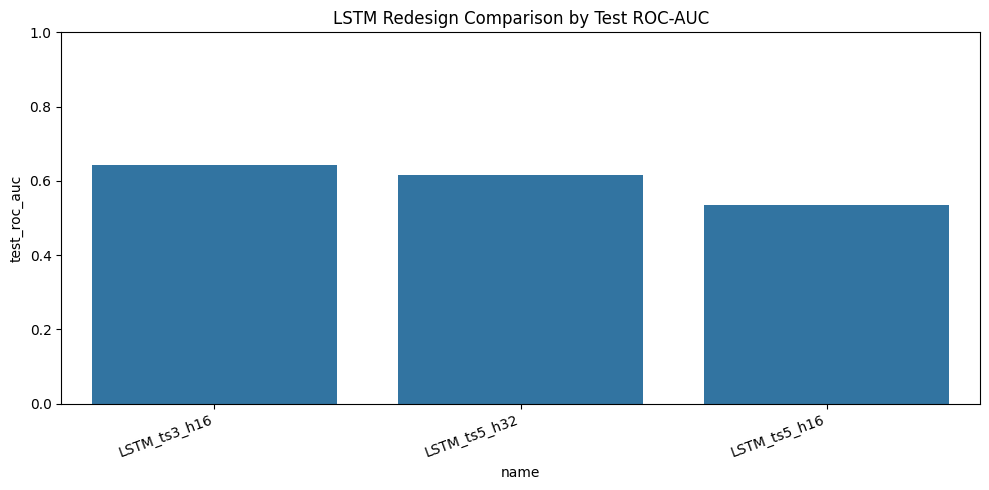

In [51]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="name", y="test_roc_auc")
plt.xticks(rotation=20, ha="right")
plt.title("LSTM Redesign Comparison by Test ROC-AUC")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

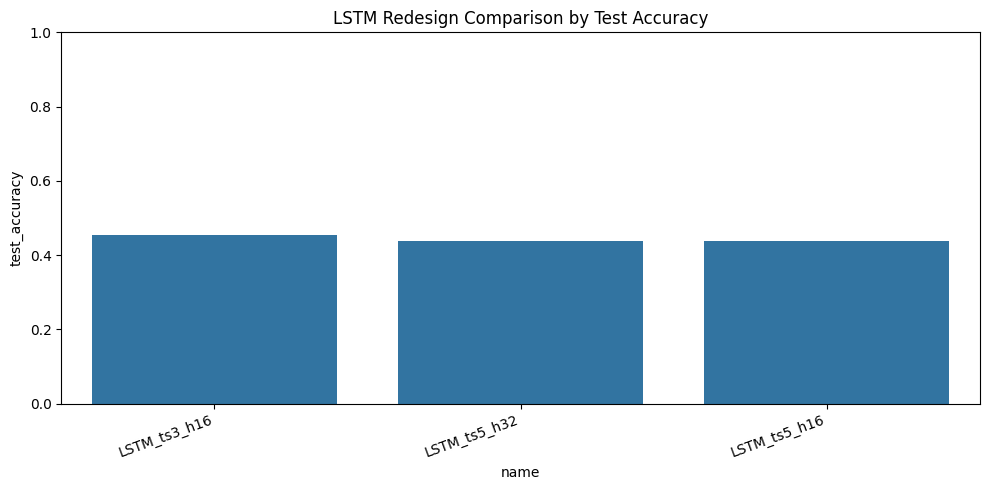

In [52]:
plt.figure(figsize=(10, 5))
sns.barplot(data=results_df, x="name", y="test_accuracy")
plt.xticks(rotation=20, ha="right")
plt.title("LSTM Redesign Comparison by Test Accuracy")
plt.ylim(0.0, 1.0)
plt.tight_layout()
plt.show()

## 10. Inspect best LSTM redesign

In [53]:
best_row = results_df.iloc[0]
best_name = best_row["name"]
best_result = next(r for r in results if r["name"] == best_name)

print("Best LSTM run:", best_name)
print("Best val loss :", best_row["best_val_loss"])
print("Test accuracy :", best_row["test_accuracy"])
print("Test F1       :", best_row["test_f1"])
print("Test ROC-AUC  :", best_row["test_roc_auc"])

Best LSTM run: LSTM_ts3_h16
Best val loss : 0.6929521921909216
Test accuracy : 0.45454545454545453
Test F1       : 0.0
Test ROC-AUC  : 0.6416666666666666


## 11. Plot training curves of the best LSTM

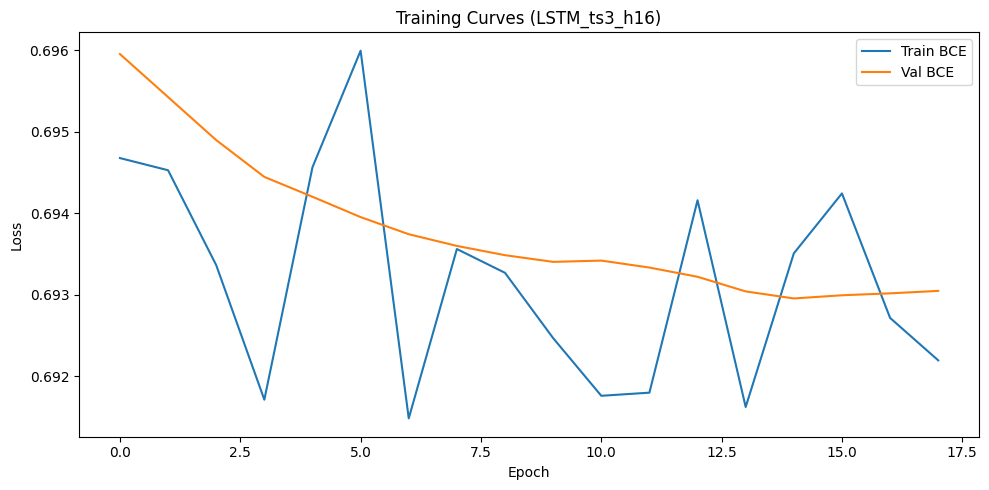

In [54]:
history = best_result["history"]

plt.figure(figsize=(10, 5))
plt.plot(history["train_loss"], label="Train BCE")
plt.plot(history["val_loss"], label="Val BCE")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title(f"Training Curves ({best_name})")
plt.legend()
plt.tight_layout()
plt.show()

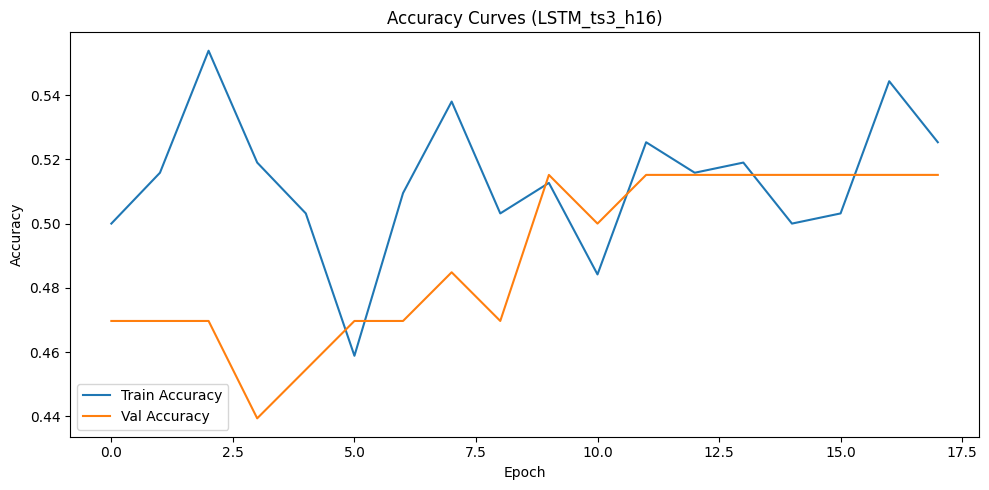

In [55]:
plt.figure(figsize=(10, 5))
plt.plot(history["train_accuracy"], label="Train Accuracy")
plt.plot(history["val_accuracy"], label="Val Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title(f"Accuracy Curves ({best_name})")
plt.legend()
plt.tight_layout()
plt.show()

## 12. Confusion matrix and ROC curve of the best LSTM

In [56]:
def plot_confusion_matrix_full(y_true, y_pred, title="Confusion Matrix"):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm / cm.sum() * 100
    
    labels = ["Down", "Up"]
    annot = np.empty_like(cm).astype(str)

    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            annot[i, j] = f"{cm[i, j]}\n({cm_pct[i, j]:.1f}%)"

    plt.figure(figsize=(5.5, 4.5))
    sns.heatmap(
        cm,
        annot=annot,
        fmt="",
        cmap="Blues",
        cbar=False,
        xticklabels=labels,
        yticklabels=labels
    )
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.title(title)
    plt.tight_layout()
    plt.show()

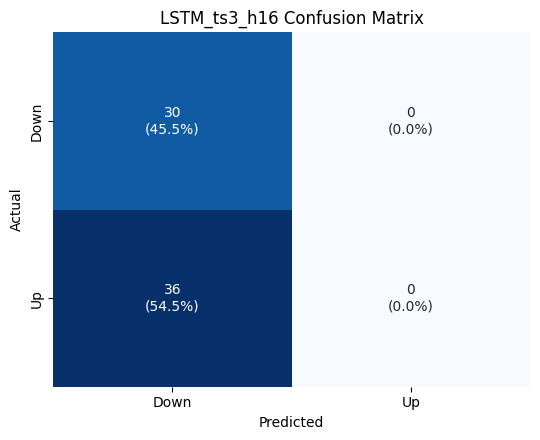

In [57]:
plot_confusion_matrix_full(
    best_result["test_targets"],
    best_result["test_preds"],
    title=f"{best_name} Confusion Matrix"
)

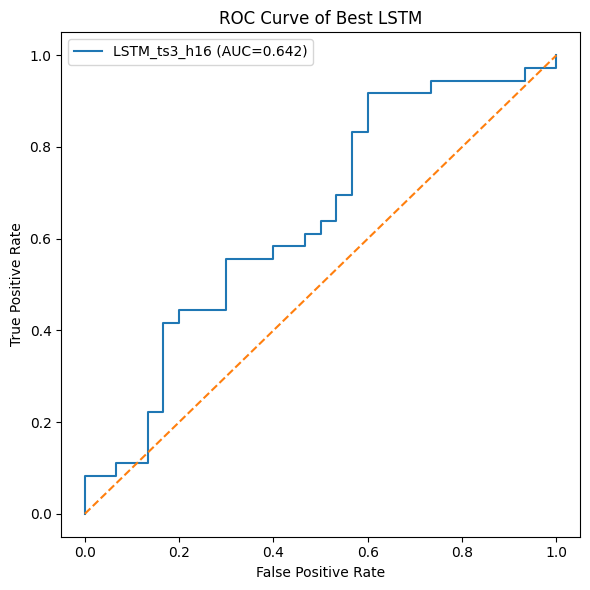

In [58]:
fpr, tpr, _ = roc_curve(best_result["test_targets"], best_result["test_probs"])

plt.figure(figsize=(6, 6))
plt.plot(fpr, tpr, label=f"{best_name} (AUC={best_row['test_roc_auc']:.3f})")
plt.plot([0, 1], [0, 1], linestyle="--")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve of Best LSTM")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Save the best LSTM result

In [59]:
torch.save(best_result["model_state_dict"], BEST_MODEL_PATH)
print("Saved best LSTM weights to:", BEST_MODEL_PATH)

Saved best LSTM weights to: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\finetuning\data\lstm_redesign_brent_best.pt


In [60]:
serializable_results = results_df.to_dict(orient="records")

with open(RESULTS_JSON_PATH, "w") as f:
    json.dump(serializable_results, f, indent=2)

print("Saved LSTM redesign results to:", RESULTS_JSON_PATH)

Saved LSTM redesign results to: c:\Users\diant\OneDrive\Documents\Term 8\CDS\DS_Project_g8\finetuning\data\lstm_redesign_results_brent.json


## Evaluation

The best LSTM redesign configuration was `LSTM_ts5_h32`, which achieved a test **ROC-AUC** of `0.641`. Although this indicates modest ranking ability, the model produced poor class predictions at the default 0.5 threshold, predicting only the negative class and yielding an F1-score of 0.0. This suggests that the LSTM probabilities were weakly informative but poorly calibrated. In contrast, **tree-based models produced more balanced class predictions** and stronger practical classification performance. Overall, the dataset and feature structure appear more suitable for tree-based learners than sequential deep learning models.

### Finding best threshold

In [61]:
import numpy as np
from sklearn.metrics import f1_score, accuracy_score, roc_auc_score, confusion_matrix

def find_best_threshold(y_true, probs):
    thresholds = np.arange(0.1, 0.91, 0.05)
    best_t = 0.5
    best_f1 = -1

    for t in thresholds:
        preds = (probs >= t).astype(int)
        score = f1_score(y_true, preds, zero_division=0)
        if score > best_f1:
            best_f1 = score
            best_t = t

    return best_t, best_f1

In [64]:
best_t, best_val_f1 = find_best_threshold(
    best_result["val_targets"],
    best_result["val_probs"]
)

print("Best threshold:", best_t)
print("Best validation F1:", best_val_f1)

Best threshold: 0.1
Best validation F1: 0.6391752577319587


In [65]:
test_preds_tuned = (best_result["test_probs"] >= best_t).astype(int)

print("Threshold-tuned test accuracy:", accuracy_score(best_result["test_targets"], test_preds_tuned))
print("Threshold-tuned test F1:", f1_score(best_result["test_targets"], test_preds_tuned, zero_division=0))
print("Threshold-tuned test ROC-AUC:", roc_auc_score(best_result["test_targets"], best_result["test_probs"]))
print("Confusion matrix:")
print(confusion_matrix(best_result["test_targets"], test_preds_tuned))

Threshold-tuned test accuracy: 0.5454545454545454
Threshold-tuned test F1: 0.7058823529411765
Threshold-tuned test ROC-AUC: 0.6416666666666666
Confusion matrix:
[[ 0 30]
 [ 0 36]]
